# 🏠 Home Price Tracker — 27980 Country Place, Athens, AL
**Jan 2021 – Jan 2026 | 3 bed / 2 bath / 1,325 sq ft**

This notebook explores estimated home values over five years using Zillow, Redfin, and Realtor.com estimates alongside 30-year fixed mortgage rates.

---

## 1. Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Auto-find the CSV no matter what the dataset was named
base = '/kaggle/input'
csv_path = next(
    os.path.join(root, f)
    for root, _, files in os.walk(base)
    for f in files if f.endswith('.csv')
)

print(f"Found: {csv_path}")
df = pd.read_csv(csv_path)
df['date'] = pd.to_datetime(df['date'])

print(f'Rows: {len(df)}')
print(f'Date range: {df["date"].min().strftime("%b %Y")} → {df["date"].max().strftime("%b %Y")}')
df.head()

Found: /kaggle/input/datasets/waltonrittenberry/monthly-house-prices/home_price_tracker_27980_country_place.csv
Rows: 61
Date range: Jan 2021 → Jan 2026


,date,zillow_zestimate,redfin_estimate,realtor_estimate,avg_estimate,monthly_change_pct,interest_rate_30yr
0,2021-01-01,185700,183800,187300,185600,0.00,2.77
1,2021-02-01,187500,188900,188600,188300,1.45,2.79
2,2021-03-01,190700,192100,189500,190800,1.33,2.81
3,2021-04-01,196400,193200,193100,194200,1.78,2.83
4,2021-05-01,198500,199300,195500,197800,1.85,2.86


## 2. Quick Summary Statistics

In [2]:
df[['zillow_zestimate', 'redfin_estimate', 'realtor_estimate', 'avg_estimate', 'interest_rate_30yr']].describe().round(2)

,zillow_zestimate,redfin_estimate,realtor_estimate,avg_estimate,interest_rate_30yr
count,61.00,61.00,61.00,61.00,61.00
mean,239168.85,237265.57,238350.82,238259.02,5.68
std,22101.87,21344.41,21393.67,21549.04,1.52
min,185700.00,183800.00,187300.00,185600.00,2.77
25%,232100.00,230600.00,231800.00,231700.00,4.54
50%,242600.00,241800.00,241800.00,241900.00,6.55
75%,253100.00,252300.00,250700.00,251300.00,6.71
max,271500.00,268000.00,269700.00,269700.00,6.91


In [3]:
# Total appreciation from Jan 2021 to Jan 2026
start = df.iloc[0]['avg_estimate']
end   = df.iloc[-1]['avg_estimate']
gain  = end - start
pct   = (gain / start) * 100

print(f'Jan 2021 avg estimate:  ${start:,.0f}')
print(f'Jan 2026 avg estimate:  ${end:,.0f}')
print(f'Total gain:             ${gain:,.0f}  ({pct:.1f}%)')
print(f'Peak estimate:          ${df["avg_estimate"].max():,.0f}  ({df.loc[df["avg_estimate"].idxmax(), "date"].strftime("%b %Y")})')

Jan 2021 avg estimate:  $185,600
Jan 2026 avg estimate:  $266,800
Total gain:             $81,200  (43.8%)
Peak estimate:          $269,700  (Nov 2025)


## 3. All Three Estimates Over Time

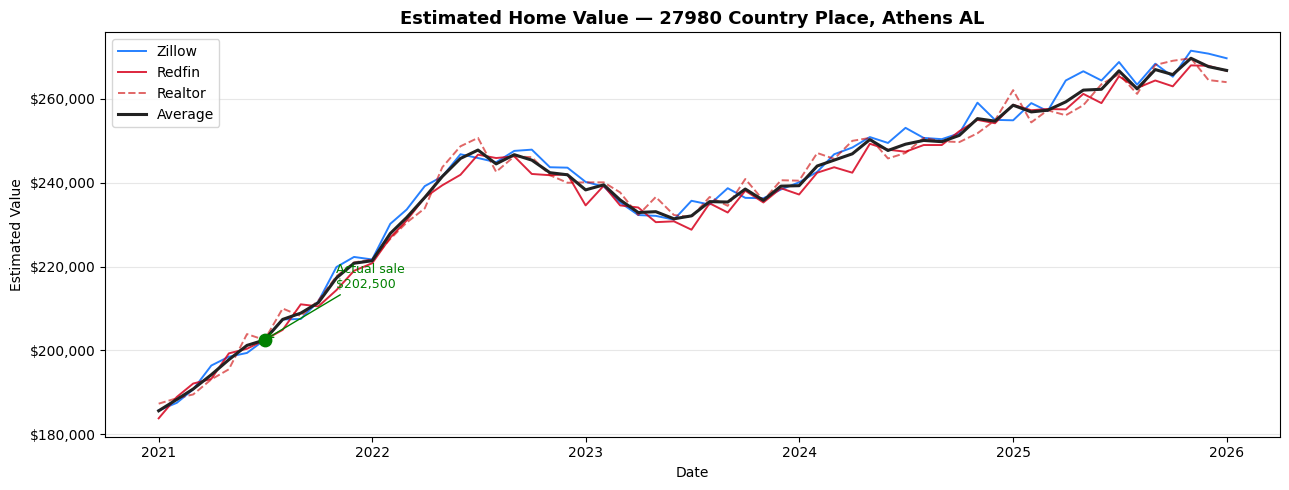

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df['date'], df['zillow_zestimate'],   label='Zillow',   color='#006aff', linewidth=1.4, alpha=0.85)
ax.plot(df['date'], df['redfin_estimate'],    label='Redfin',   color='#d6001c', linewidth=1.4, alpha=0.85)
ax.plot(df['date'], df['realtor_estimate'],   label='Realtor',  color='#cc0000', linewidth=1.4, alpha=0.6, linestyle='--')
ax.plot(df['date'], df['avg_estimate'],       label='Average',  color='#222222', linewidth=2.2)

# Mark actual sale
sale_row = df[df['date'] == '2021-07-01']
ax.scatter(sale_row['date'], sale_row['avg_estimate'], color='green', zorder=5, s=80)
ax.annotate('Actual sale\n$202,500',
            xy=(sale_row['date'].values[0], 202500),
            xytext=(pd.Timestamp('2021-11-01'), 215000),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Estimated Home Value — 27980 Country Place, Athens AL', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Estimated Value')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Average Estimate vs. 30-Year Mortgage Rate

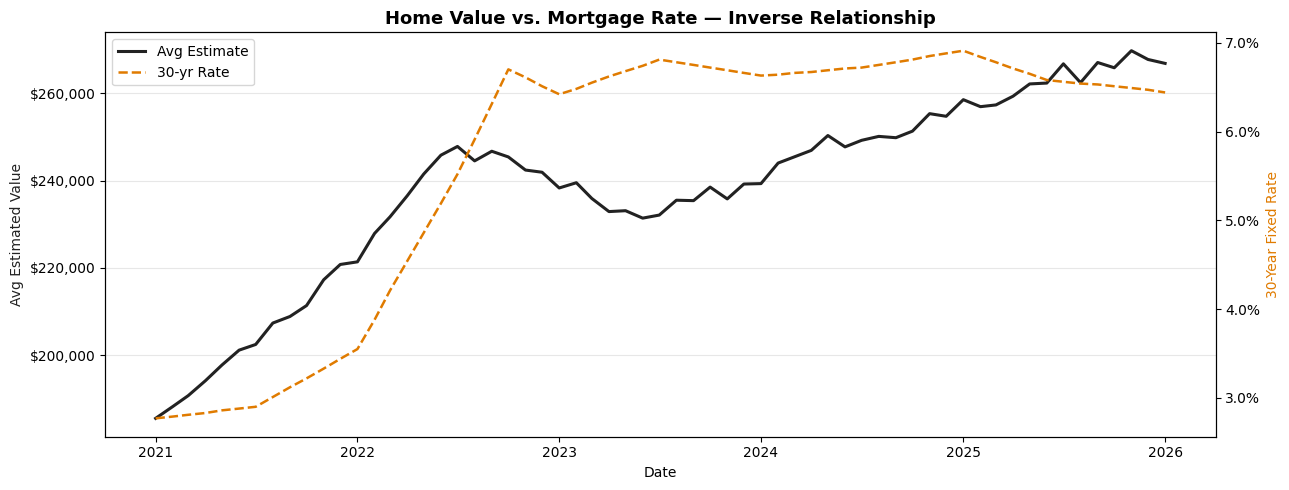

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()

ax1.plot(df['date'], df['avg_estimate'],       color='#222222', linewidth=2.2, label='Avg Estimate')
ax2.plot(df['date'], df['interest_rate_30yr'], color='#e07b00', linewidth=1.8, linestyle='--', label='30-yr Rate')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

ax1.set_ylabel('Avg Estimated Value', color='#222222')
ax2.set_ylabel('30-Year Fixed Rate', color='#e07b00')
ax1.set_xlabel('Date')
ax1.set_title('Home Value vs. Mortgage Rate — Inverse Relationship', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Monthly Change %

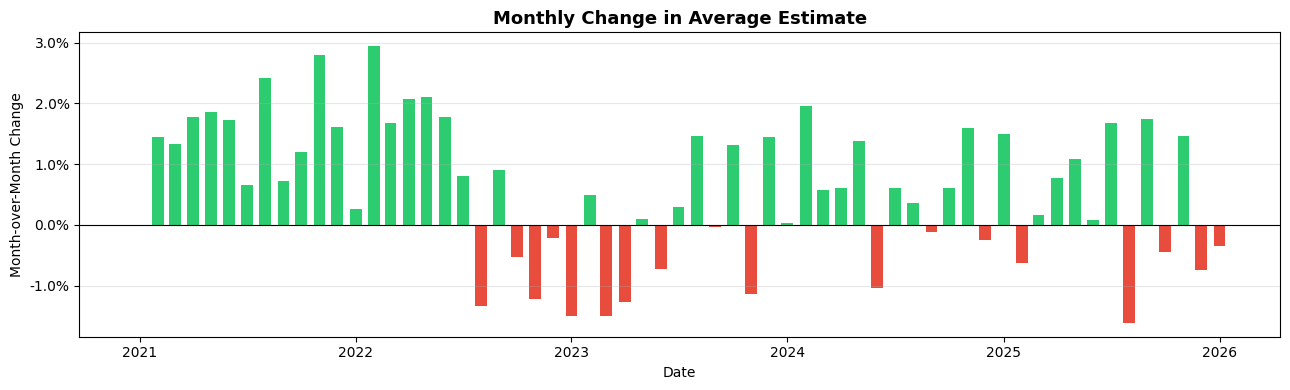

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(13, 4))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df['monthly_change_pct']]
ax.bar(df['date'], df['monthly_change_pct'], color=colors, width=20)
ax.axhline(0, color='black', linewidth=0.8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title('Monthly Change in Average Estimate', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Month-over-Month Change')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Year-over-Year Appreciation

In [7]:
# Group by year, take January value for each year
annual = df[df['date'].dt.month == 1][['date', 'avg_estimate']].copy()
annual['year'] = annual['date'].dt.year
annual['yoy_change_pct'] = annual['avg_estimate'].pct_change() * 100
annual['yoy_change_dollars'] = annual['avg_estimate'].diff()
annual = annual.dropna()
annual[['year', 'avg_estimate', 'yoy_change_dollars', 'yoy_change_pct']].rename(
    columns={
        'avg_estimate': 'Jan Avg Estimate',
        'yoy_change_dollars': 'YoY $ Change',
        'yoy_change_pct': 'YoY % Change'
    }
).round(2)

,year,Jan Avg Estimate,YoY $ Change,YoY % Change
12,2022,221400,35800.0,19.29
24,2023,238300,16900.0,7.63
36,2024,239300,1000.0,0.42
48,2025,258500,19200.0,8.02
60,2026,266800,8300.0,3.21


## 7. Which Source Runs Highest?
Compare the average estimate from each platform across the full period.

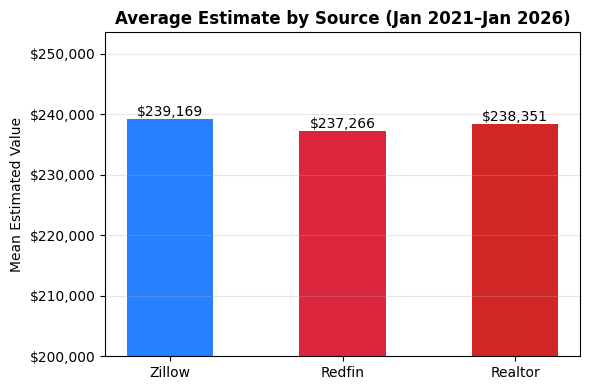

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

source_avgs = {
    'Zillow':  df['zillow_zestimate'].mean(),
    'Redfin':  df['redfin_estimate'].mean(),
    'Realtor': df['realtor_estimate'].mean(),
}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(source_avgs.keys(), source_avgs.values(),
              color=['#006aff', '#d6001c', '#cc0000'], alpha=0.85, width=0.5)

for bar, val in zip(bars, source_avgs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', fontsize=10)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(200000, max(source_avgs.values()) * 1.06)
ax.set_title('Average Estimate by Source (Jan 2021–Jan 2026)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Estimated Value')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()